In [3]:
pip install catboost


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from catboost import CatBoostRegressor
import joblib

In [12]:
df = pd.read_csv("../data/processed/final_dataset.csv")

print(df.shape)
df.head()

(15000, 47)


,Agmt Id,Cust Age,Cust Gender,Cust Cibil Score,Cust Employment Type,Cust Net Salary,Coborrower Flag,App Score Risk,Agmt Date,Seizure Date,...,Asset Enginecondition,Asset Accident Flag,Traiffic Challan Amount,Target Sold Amount At Liquidation,Asset_Health_Index,Recovery_Efficiency_Index,LGD,LGD_pct,Depreciation_Pct,Asset_Age_Group
0,ASSET_1,29,F,-1,NREGI,30000,N,LOW RISK,2023-12-27,2025-05-23,...,G,No,0,37000.0,100.0,78.834107,9934.0,21.165893,54.320988,1-2 Years
1,ASSET_2,24,M,-1,NREGI,60000,N,LOW RISK,2025-11-20,2026-05-31,...,G,No,0,56000.0,100.0,65.745448,29177.0,34.254552,47.565543,0-1 Year
2,ASSET_3,32,F,763,AGR,29500,N,LOW RISK,2024-05-16,2025-06-24,...,A,No,0,40500.0,70.0,78.369754,11178.1,21.630246,49.783013,1-2 Years
3,ASSET_4,25,F,-1,NREGI,40000,N,MEDIUM RISK,2025-10-24,2026-04-30,...,A,No,0,49000.0,70.0,74.384431,16874.0,25.615569,40.606061,0-1 Year
4,ASSET_5,59,F,653,SAL,45000,N,MEDIUM RISK,2024-09-20,2025-05-30,...,G,No,0,46000.0,100.0,69.099157,20571.0,30.900843,44.242424,0-1 Year


In [7]:
target = "Target Sold Amount At Liquidation"

4. Drop Leakage Columns

Do NOT use columns that would only be known after liquidation.

In [13]:
drop_cols = [

    # ID
    "Agmt Id",

    # Target
    target,

    # Future information
    "Sold Date",
    "Sold Date Month",
    "Sold Date Year",

    "Seizure Date",
    "Seizure Date Month",
    "Seizure Date Year",

    # Post-default information
    "OS Balance At Liquidation",
    "Asset Age Months At Seizure",
    "Months Spent In Yard",

    # Leakage features
    "Recovery_Efficiency_Index",
    "LGD",
    "LGD_pct",
    "Depreciation_Pct",

    # Previous prediction
    "Residual_Value_Forecast"
]

5. Find Categorical Features

In [14]:


X = df.drop(
    columns=drop_cols,
    errors="ignore"
)

y = df[target]

print(X.shape)

(15000, 32)


In [15]:
cat_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

cat_features

/var/folders/3d/k19xjnj973gcp_jcrjmjhl200000gn/T/ipykernel_12014/1010382868.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(


['Cust Gender',
 'Cust Employment Type',
 'Coborrower Flag',
 'App Score Risk',
 'Agmt Date',
 'Cust Branch',
 'Cust Region',
 'Cust State',
 'Pincode Tier',
 'RC Availability',
 'Registration Flag',
 'Asset Variant',
 'Asset Model',
 'Asset Fuel Type',
 'Asset Bodycondition',
 'Asset Tyrecondition',
 'Asset Generalcondition',
 'Asset Enginecondition',
 'Asset Accident Flag',
 'Asset_Age_Group']

6. Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

7. Train CatBoost

In [17]:
model = CatBoostRegressor(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    loss_function="RMSE",
    eval_metric="RMSE",
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

0:	learn: 16126.3147324	total: 67ms	remaining: 1m 6s
100:	learn: 8695.0823724	total: 984ms	remaining: 8.76s
200:	learn: 8117.9294180	total: 1.93s	remaining: 7.67s
300:	learn: 7745.8886574	total: 2.89s	remaining: 6.71s
400:	learn: 7445.2251910	total: 3.84s	remaining: 5.73s
500:	learn: 7173.0728563	total: 4.83s	remaining: 4.81s
600:	learn: 6933.6487178	total: 5.86s	remaining: 3.89s
700:	learn: 6689.2172979	total: 6.84s	remaining: 2.92s
800:	learn: 6462.4504690	total: 7.8s	remaining: 1.94s
900:	learn: 6260.8085078	total: 8.79s	remaining: 966ms
999:	learn: 6063.0455146	total: 9.74s	remaining: 0us


CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1000, learning_rate=0.05, loss_function='RMSE', verbose=100)

8. Predictions

In [18]:
preds = model.predict(X_test)

9. Metrics

In [19]:
mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

r2 = r2_score(
    y_test,
    preds
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 6255.842181432281
RMSE: 8322.01468566363
R2  : 0.7486869187355588


10. Feature Importance

Very important for presentation.




In [20]:
fi = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
})

fi = fi.sort_values(
    by="Importance",
    ascending=False
)

fi.head(20)

,Feature,Importance
19,Asset Model,18.670595
31,Asset_Age_Group,11.443260
12,Cust State,7.681151
10,Cust Branch,6.906634
21,Asset Cost At Disbursal,6.620870
22,Loan Amount,5.377578
18,Asset Variant,5.201955
11,Cust Region,4.499377
7,Agmt Date,3.186040
26,Asset Generalcondition,3.039218


Save Model


In [21]:
import os

os.makedirs(
    "../models",
    exist_ok=True
)

In [22]:
joblib.dump(
    model,
    "../models/catboost_residual.pkl"
)

print("Model Saved")

Model Saved


Create Residual Value Forecast For Entire Dataset

In [23]:
df["Residual_Value_Forecast"] = model.predict(X)

df[
    [
        "Asset Cost At Disbursal",
        "Target Sold Amount At Liquidation",
        "Residual_Value_Forecast"
    ]
].head()

,Asset Cost At Disbursal,Target Sold Amount At Liquidation,Residual_Value_Forecast
0,81000,37000.0,31061.247508
1,106800,56000.0,49192.500708
2,80650,40500.0,35015.205663
3,82500,49000.0,38754.405520
4,82500,46000.0,40817.718654


Save Forecast Dataset

In [24]:
df.to_csv(
    "../data/processed/final_forecast_dataset.csv",
    index=False
)

print("Forecast Dataset Saved")

Forecast Dataset Saved


11. Plot Importance

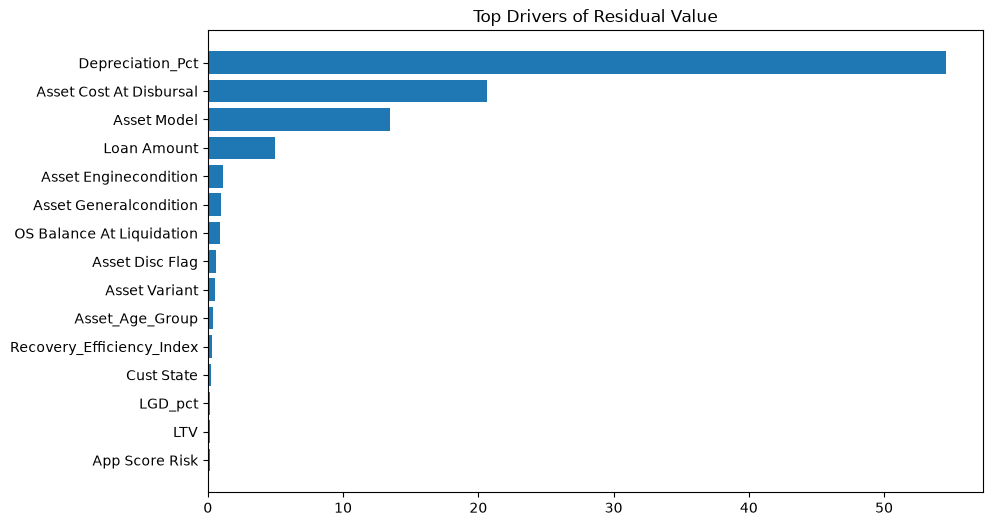

In [ ]:
import matplotlib.pyplot as plt

top = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top Drivers of Residual Value"
)

plt.show()


12. Forecast Entire Portfolio

In [ ]:

df["Residual_Value_Forecast"] = model.predict(X)

df[
    [
        "Agmt Id",
        "Residual_Value_Forecast"
    ]
].head()


,Agmt Id,Residual_Value_Forecast
0,ASSET_1,36906.732779
1,ASSET_2,55688.258560
2,ASSET_3,40512.224683
3,ASSET_4,49020.777115
4,ASSET_5,46040.128920


13. Save Predictions

In [ ]:

df.to_csv(
    "../data/processed/final_forecast_dataset.csv",
    index=False
)

print("Forecast dataset saved")


Forecast dataset saved


14. Save Model

In [ ]:
pip install joblib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:

import joblib

joblib.dump(
    model,
    "../models/catboost_residual.pkl"
)

print("Model saved")

Model saved


In [ ]:
feature_importance.head(20)

,Feature,Importance
40,Depreciation_Pct,54.574015
24,Asset Cost At Disbursal,20.632836
22,Asset Model,13.432019
25,Loan Amount,4.992117
33,Asset Enginecondition,1.139744
32,Asset Generalcondition,1.008265
27,OS Balance At Liquidation,0.933402
19,Asset Disc Flag,0.616569
21,Asset Variant,0.543238
41,Asset_Age_Group,0.364914


In [ ]:
for col in [
    "OS Balance At Liquidation",
    "Asset Age Months At Seizure",
    "Months Spent In Yard",
    "Seizure Date",
    "Seizure Date Month",
    "Seizure Date Year",
    "Residual_Risk_Score",
    "Risk_Band",
    "Profitability_Score"
]:
    print(col, col in X.columns)

OS Balance At Liquidation True
Asset Age Months At Seizure True
Months Spent In Yard True
Seizure Date True
Seizure Date Month True
Seizure Date Year True
Residual_Risk_Score False
Risk_Band False
Profitability_Score False


In [ ]:
print(X.shape)
print(X.columns.tolist())

(15000, 32)
['Cust Age', 'Cust Gender', 'Cust Cibil Score', 'Cust Employment Type', 'Cust Net Salary', 'Coborrower Flag', 'App Score Risk', 'Agmt Date', 'Tenure', 'Cust Net IRR', 'Cust Branch', 'Cust Region', 'Cust State', 'Pincode Tier', 'RC Availability', 'Registration Flag', 'Asset Disc Flag', 'Asset Alloy Flag', 'Asset Variant', 'Asset Model', 'Asset Fuel Type', 'Asset Cost At Disbursal', 'Loan Amount', 'LTV', 'Asset Bodycondition', 'Asset Tyrecondition', 'Asset Generalcondition', 'Asset Enginecondition', 'Asset Accident Flag', 'Traiffic Challan Amount', 'Asset_Health_Index', 'Asset_Age_Group']


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance.sort_values(
    "Importance",
    ascending=False
).head(20)

,Feature,Importance
19,Asset Model,18.670595
31,Asset_Age_Group,11.443260
12,Cust State,7.681151
10,Cust Branch,6.906634
21,Asset Cost At Disbursal,6.620870
22,Loan Amount,5.377578
18,Asset Variant,5.201955
11,Cust Region,4.499377
7,Agmt Date,3.186040
26,Asset Generalcondition,3.039218


In [ ]:
df["Residual_Value_Forecast"] = model.predict(X)

In [ ]:
df[
    [
        "Asset Cost At Disbursal",
        "Target Sold Amount At Liquidation",
        "Residual_Value_Forecast"
    ]
].head()

,Asset Cost At Disbursal,Target Sold Amount At Liquidation,Residual_Value_Forecast
0,81000,37000.0,31061.247508
1,106800,56000.0,49192.500708
2,80650,40500.0,35015.205663
3,82500,49000.0,38754.405520
4,82500,46000.0,40817.718654


In [ ]:
df.to_csv(
    "../data/processed/final_dataset_with_forecast.csv",
    index=False
)

In [ ]:
import joblib

model = joblib.load("../models/catboost_residual.pkl")

In [ ]:
target = "Target Sold Amount At Liquidation"

drop_cols = [
    "Agmt Id",
    target,
    "Sold Date",
    "Sold Date Month",
    "Sold Date Year",
    "Seizure Date",
    "Seizure Date Month",
    "Seizure Date Year",
    "OS Balance At Liquidation",
    "Asset Age Months At Seizure",
    "Months Spent In Yard",
    "Residual_Value_Forecast",
    "Depreciation_Pct",
    "Recovery_Efficiency_Index",
    "LGD",
    "LGD_pct"
]

X = df.drop(columns=drop_cols, errors="ignore")

In [ ]:
df["Residual_Value_Forecast"] = model.predict(X)